In [1]:
# just one time run this cell
import sys
import os
sys.path.append(os.path.abspath('../'))

In [2]:
from src.genetic import genetic_tsp,draw_tsp_graph
import matplotlib.pyplot as plt
import numpy as np

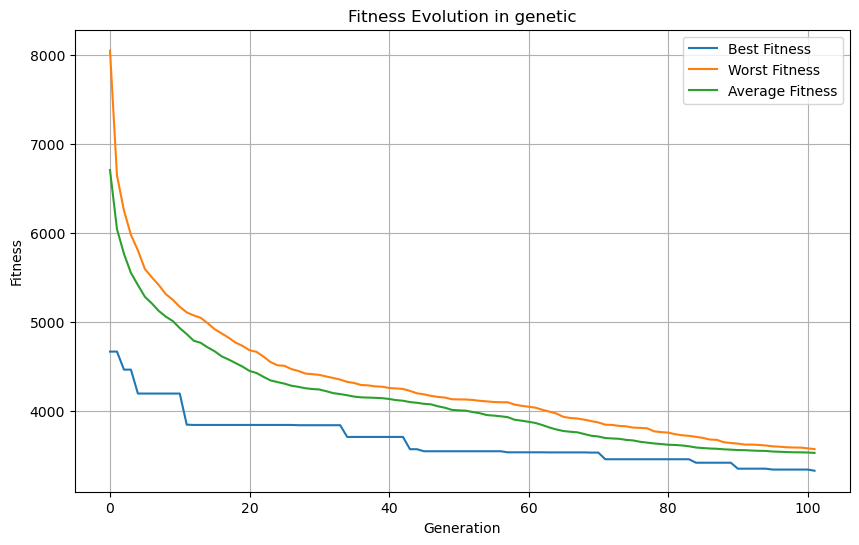

Best Solution :	 [ 5 11  6 12  7 10  8  9  0  1 13  2  3  4] 
		Generation : 	 101 
		Fitness : 	 3323.0


In [3]:
max_generation = 300
solfit = 3323.0
tsp_file_path = "../data/burma14.tsp"

best_fitness_values, worst_fitness_values, avg_fitness_values, best_sol, best_gen, G = genetic_tsp(tsp_file_path,100,0.9,0.1,max_generation,solfitness=solfit)
plt.figure(figsize=(10, 6))
plt.plot(range(len(best_fitness_values)),best_fitness_values, label='Best Fitness')
plt.plot(range(len(best_fitness_values)),worst_fitness_values, label='Worst Fitness')
plt.plot(range(len(best_fitness_values)),avg_fitness_values, label='Average Fitness')
plt.xlabel('Generation')
plt.ylabel('Fitness')
plt.title('Fitness Evolution in genetic')
plt.legend()
plt.grid(True)
plt.show()
print("Best Solution :\t",best_sol,"\n\t\tGeneration : \t",best_gen,"\n\t\tFitness : \t",best_fitness_values[-1])

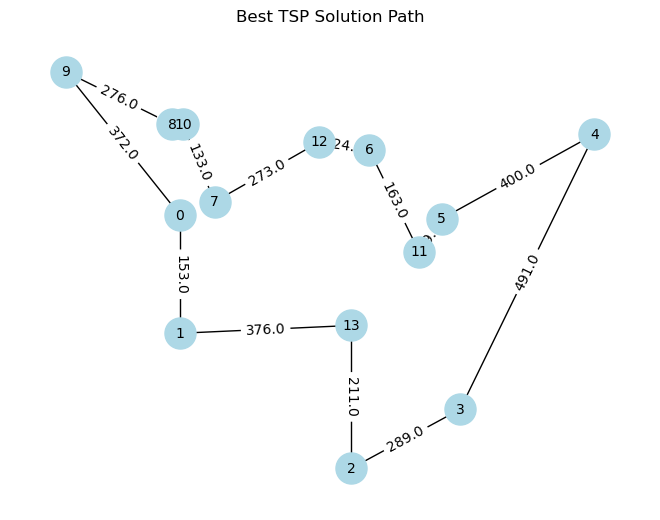

In [4]:
draw_tsp_graph(G)

In [5]:
num_runs=5

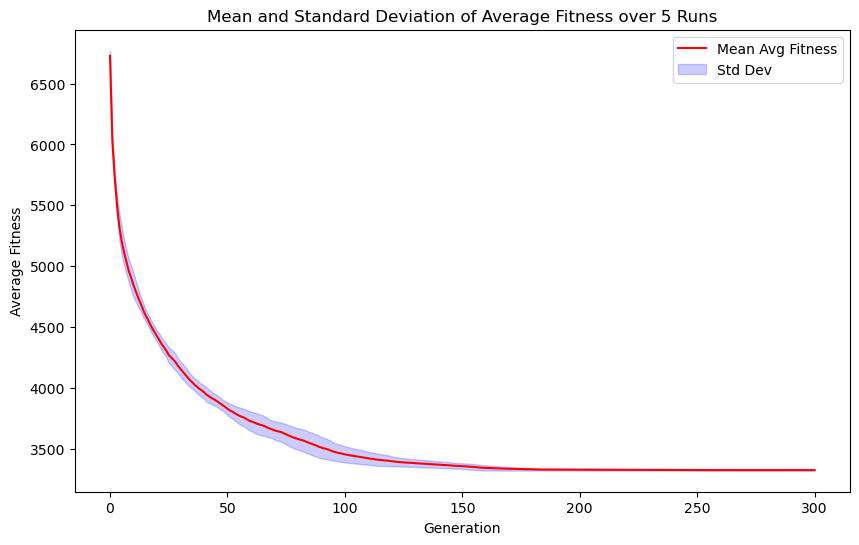

In [6]:
fitness_values = []

for _ in range(num_runs):
    _, _, avg_fitness_values,_,_,_= genetic_tsp(tsp_file_path,100,0.9,0.1,max_generation)
    avg_fitness_values = np.pad(avg_fitness_values, (0, max_generation+1 - len(avg_fitness_values)), 'constant', constant_values=np.nan)
    fitness_values.append(avg_fitness_values)

fitness_values = np.array(fitness_values)
mean_avg_fitness = np.mean(fitness_values, axis=0)
std_avg_fitness = np.std(fitness_values, axis=0)

generations = np.arange(len(mean_avg_fitness))
plt.figure(figsize=(10, 6))
plt.plot(generations, mean_avg_fitness, label='Mean Avg Fitness', color='red')
plt.fill_between(generations, mean_avg_fitness - std_avg_fitness, mean_avg_fitness + std_avg_fitness, color='b', alpha=0.2, label='Std Dev')
plt.xlabel('Generation')
plt.ylabel('Average Fitness')
plt.title('Mean and Standard Deviation of Average Fitness over 5 Runs')
plt.legend()
plt.show()

	Best fitness: 3323.0
			Generation: 104
	Best fitness: 3323.0
			Generation: 82
	Best fitness: 3323.0
			Generation: 158
	Best fitness: 3323.0
			Generation: 136
	Best fitness: 3323.0
			Generation: 95
Avg last generation: 3323.0


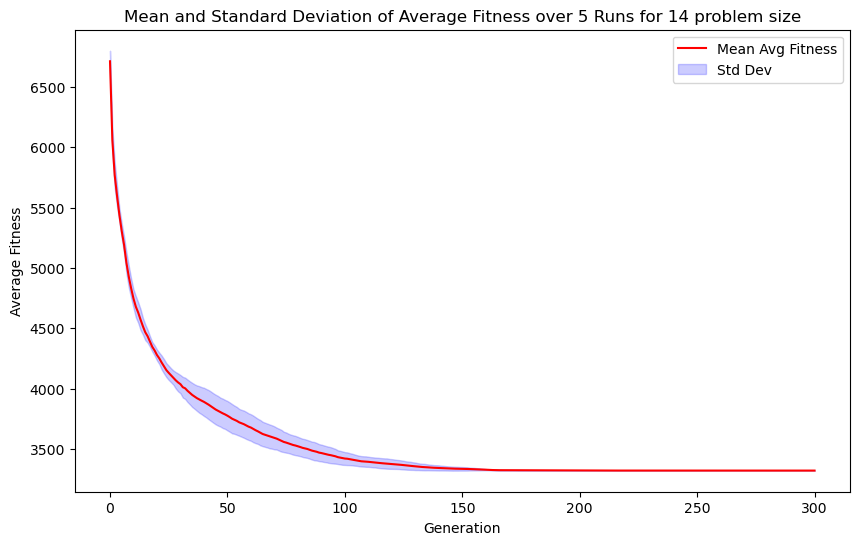

	Best fitness: 2344.0
			Generation: 232
	Best fitness: 2157.0
			Generation: 292
	Best fitness: 2184.0
			Generation: 255
	Best fitness: 2091.0
			Generation: 273
	Best fitness: 2254.0
			Generation: 277
Avg last generation: 2445.528


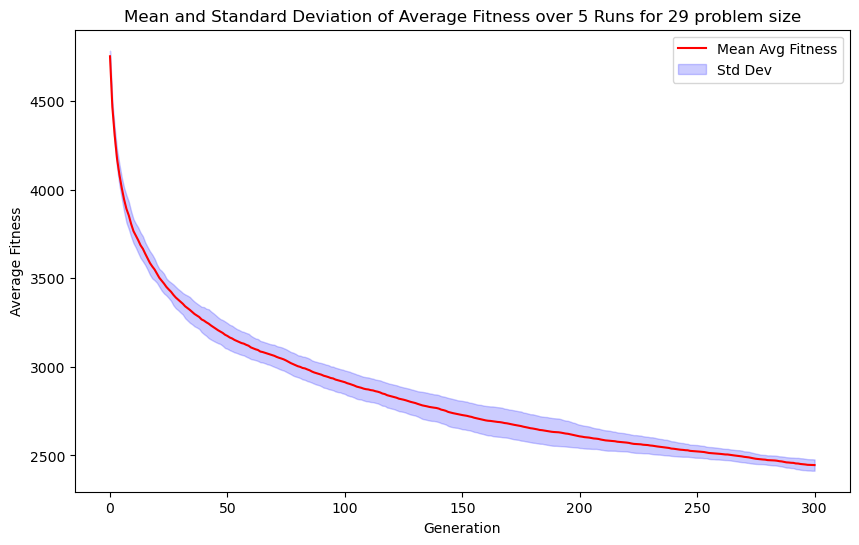

	Best fitness: 1489.0
			Generation: 230
	Best fitness: 1524.0
			Generation: 299
	Best fitness: 1389.0
			Generation: 145
	Best fitness: 1508.0
			Generation: 276
	Best fitness: 1511.0
			Generation: 284
Avg last generation: 1611.8580000000002


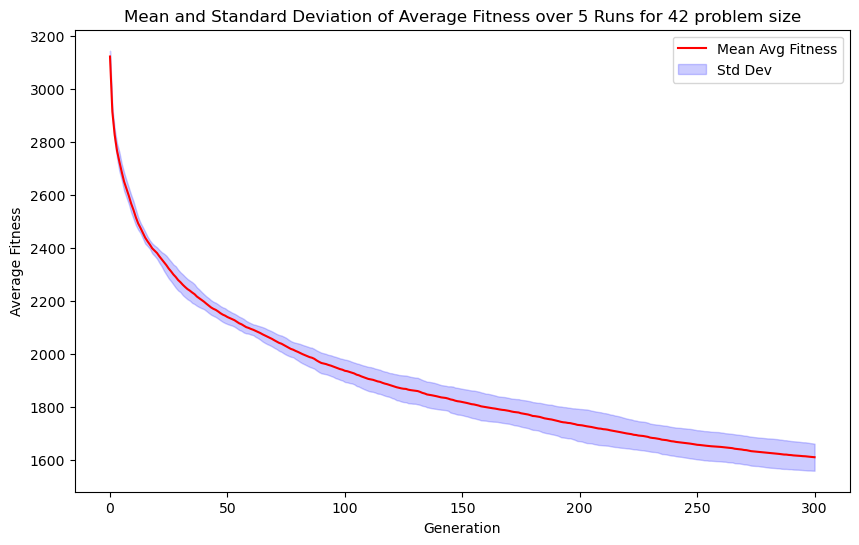

	Best fitness: 36446.0
			Generation: 264
	Best fitness: 35912.0
			Generation: 278
	Best fitness: 36780.0
			Generation: 215
	Best fitness: 36078.0
			Generation: 220
	Best fitness: 36512.0
			Generation: 204
Avg last generation: 38645.094


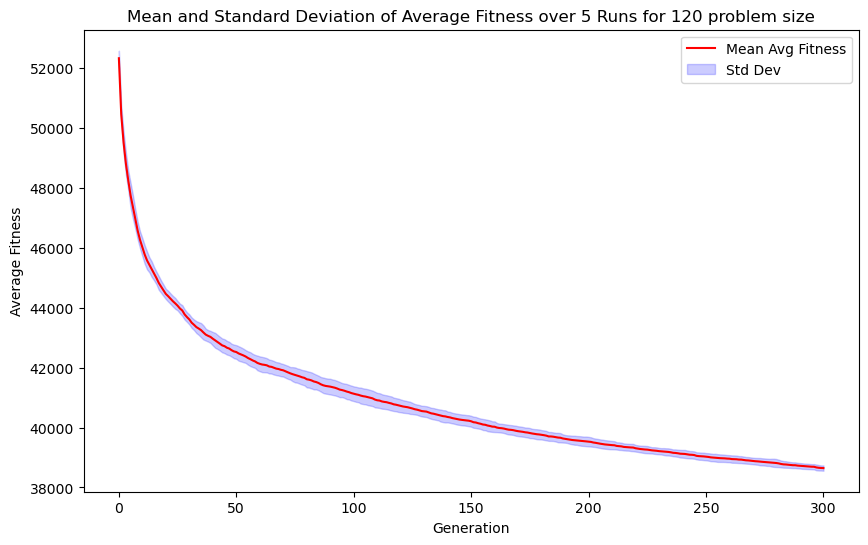

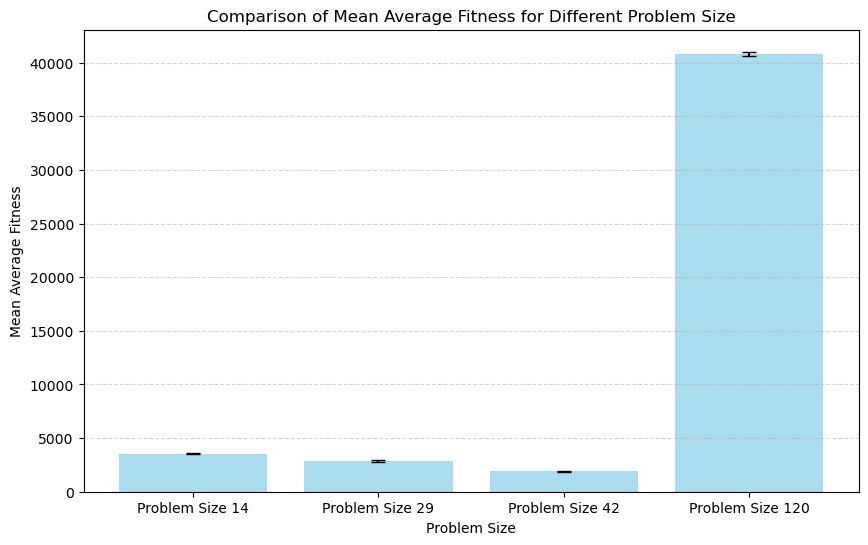

In [7]:
prob_file_paths = ["burma14.tsp","bayg29.tsp","dantzig42.tsp","gr120.tsp"] 
probsize = [14,29,42,120]
all_mean_avg_fitness = []
all_std_avg_fitness = []

for i in range(len(probsize)):
    fitness_values = []
    for _ in range(num_runs):
        bf, _, avg_fitness_values,_,bestgen,_ = genetic_tsp("../data/"+prob_file_paths[i],100,0.9,0.1,max_generation)
        avg_fitness_values = np.pad(avg_fitness_values, (0, max_generation + 1 - len(avg_fitness_values)), 'constant', constant_values=np.nan)
        fitness_values.append(avg_fitness_values)
        print("\tBest fitness:",bf[bestgen])
        print("\t\t\tGeneration:",bestgen)

    fitness_values = np.array(fitness_values)
    mean_avg_fitness = np.mean(fitness_values, axis=0)
    std_avg_fitness = np.std(fitness_values, axis=0)
    print("Avg last generation:",mean_avg_fitness[-1])
    generations = np.arange(len(mean_avg_fitness))
    plt.figure(figsize=(10, 6))
    plt.plot(generations, mean_avg_fitness, label='Mean Avg Fitness', color='red')
    plt.fill_between(generations, mean_avg_fitness - std_avg_fitness, mean_avg_fitness + std_avg_fitness, color='b', alpha=0.2, label='Std Dev')
    plt.xlabel('Generation')
    plt.ylabel('Average Fitness')
    plt.title(f'Mean and Standard Deviation of Average Fitness over 5 Runs for {probsize[i]} problem size')
    plt.legend()
    plt.show()
    all_mean_avg_fitness.append(np.nanmean(mean_avg_fitness))
    all_std_avg_fitness.append(np.nanmean(std_avg_fitness))

plt.figure(figsize=(10, 6))
x = np.arange(len(prob_file_paths))
plt.bar(x, all_mean_avg_fitness, yerr=all_std_avg_fitness, capsize=5, alpha=0.7, color='skyblue')

plt.xticks(x, [f'Problem Size {p}' for p in probsize])
plt.xlabel('Problem Size')
plt.ylabel('Mean Average Fitness')
plt.title('Comparison of Mean Average Fitness for Different Problem Size')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


	Best fitness: 3323.0
			Generation: 163
	Best fitness: 3323.0
			Generation: 113
	Best fitness: 3323.0
			Generation: 92
	Best fitness: 3323.0
			Generation: 70
	Best fitness: 3323.0
			Generation: 89


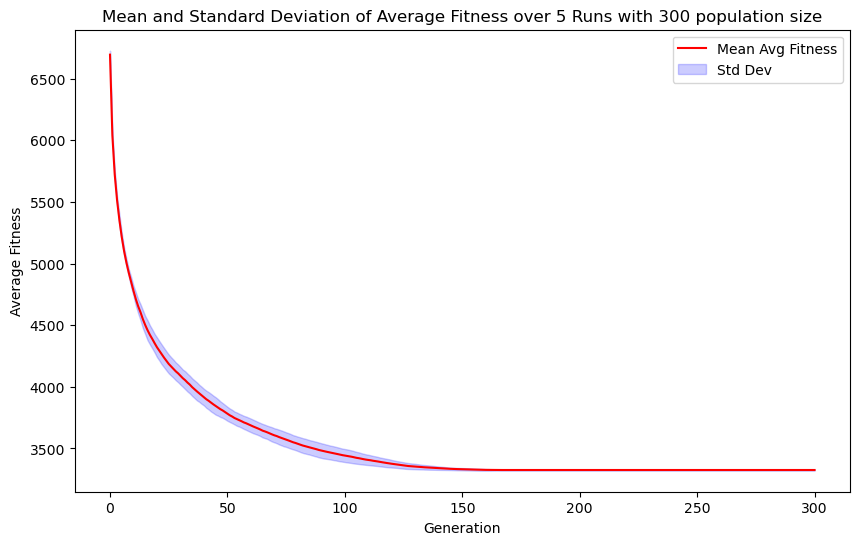

	Best fitness: 3323.0
			Generation: 135
	Best fitness: 3323.0
			Generation: 92
	Best fitness: 3323.0
			Generation: 88
	Best fitness: 3323.0
			Generation: 109
	Best fitness: 3323.0
			Generation: 77


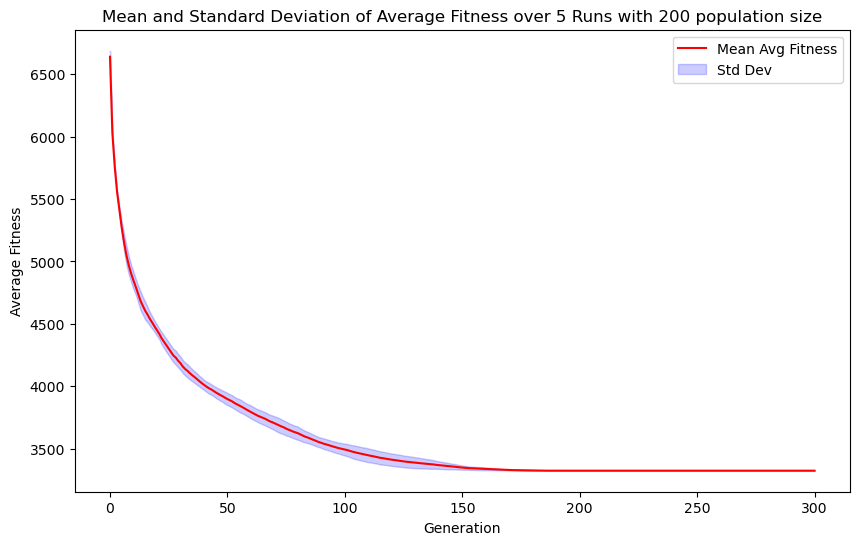

	Best fitness: 3323.0
			Generation: 77
	Best fitness: 3323.0
			Generation: 129
	Best fitness: 3323.0
			Generation: 112
	Best fitness: 3323.0
			Generation: 179
	Best fitness: 3323.0
			Generation: 245


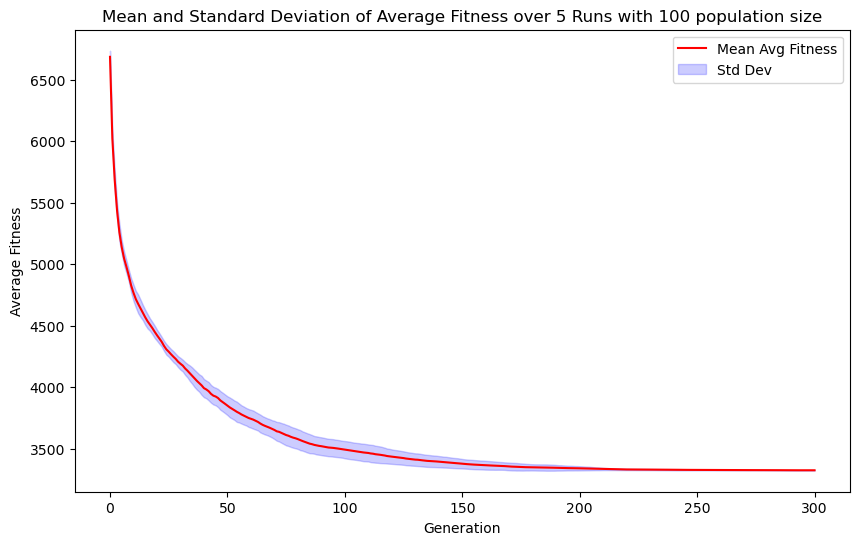

	Best fitness: 3323.0
			Generation: 113
	Best fitness: 3336.0
			Generation: 227
	Best fitness: 3323.0
			Generation: 78
	Best fitness: 3323.0
			Generation: 112
	Best fitness: 3323.0
			Generation: 158


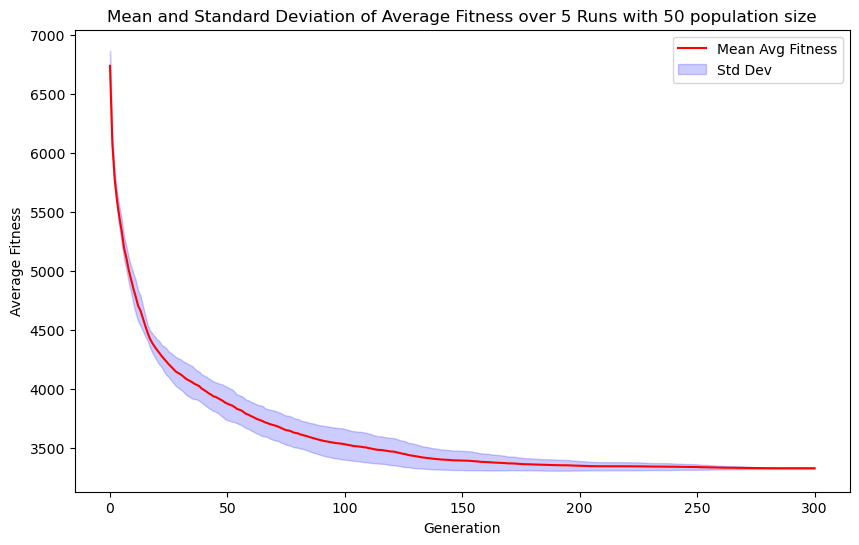

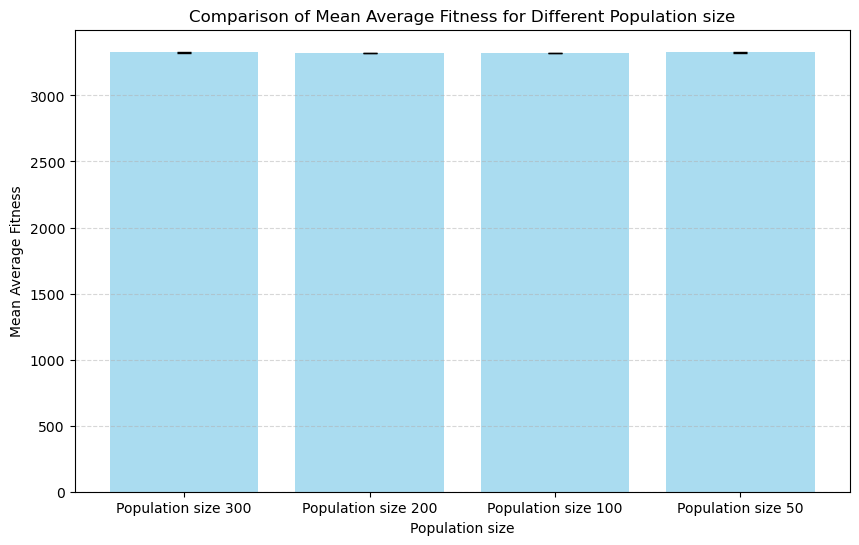

In [8]:
pop_sizes = [300, 200, 100, 50]
all_mean_avg_fitness = []
all_std_avg_fitness = []
tsp_file_path = "../data/burma14.tsp"
for pop_size in pop_sizes:
    fitness_values = []
    for _ in range(num_runs):
        bf, _, avg_fitness_values,_,best_gen,_ = genetic_tsp(tsp_file_path,pop_size,0.9,0.1,max_generation)
        avg_fitness_values = np.pad(avg_fitness_values, (0, max_generation+1 - len(avg_fitness_values)), 'constant', constant_values=np.nan)
        fitness_values.append(avg_fitness_values)
        print("\tBest fitness:",bf[best_gen])
        print("\t\t\tGeneration:",best_gen)
        
    fitness_values = np.array(fitness_values)
    mean_avg_fitness = np.mean(fitness_values, axis=0)
    std_avg_fitness = np.std(fitness_values, axis=0)
    generations = np.arange(len(mean_avg_fitness))
    plt.figure(figsize=(10, 6))
    plt.plot(generations, mean_avg_fitness, label='Mean Avg Fitness', color='red')
    plt.fill_between(generations, mean_avg_fitness - std_avg_fitness, mean_avg_fitness + std_avg_fitness, color='b', alpha=0.2, label='Std Dev')
    plt.xlabel('Generation')
    plt.ylabel('Average Fitness')
    plt.title(f'Mean and Standard Deviation of Average Fitness over 5 Runs with {pop_size} population size')
    plt.legend()
    plt.show()
    all_mean_avg_fitness.append(mean_avg_fitness[-1])
    all_std_avg_fitness.append(std_avg_fitness[-1])

plt.figure(figsize=(10, 6))
x = np.arange(len(pop_sizes))
plt.bar(x, all_mean_avg_fitness, yerr=all_std_avg_fitness, capsize=5, alpha=0.7, color='skyblue')

plt.xticks(x, [f'Population size {p}' for p in pop_sizes])
plt.xlabel('Population size')
plt.ylabel('Mean Average Fitness')
plt.title('Comparison of Mean Average Fitness for Different Population size')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

	Best fitness: 3323.0
			Generation: 113
	Best fitness: 3323.0
			Generation: 106
	Best fitness: 3323.0
			Generation: 154
	Best fitness: 3336.0
			Generation: 176
	Best fitness: 3323.0
			Generation: 91


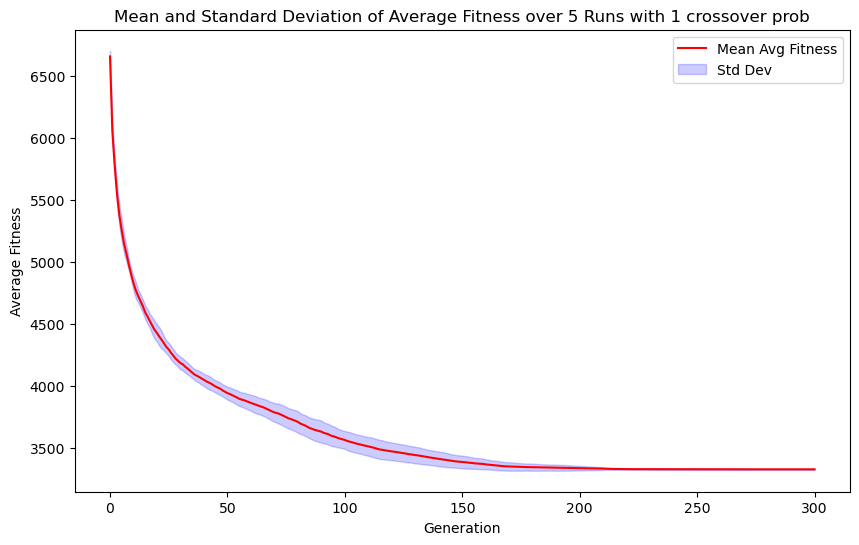

	Best fitness: 3323.0
			Generation: 144
	Best fitness: 3336.0
			Generation: 251
	Best fitness: 3323.0
			Generation: 88
	Best fitness: 3323.0
			Generation: 100
	Best fitness: 3323.0
			Generation: 140


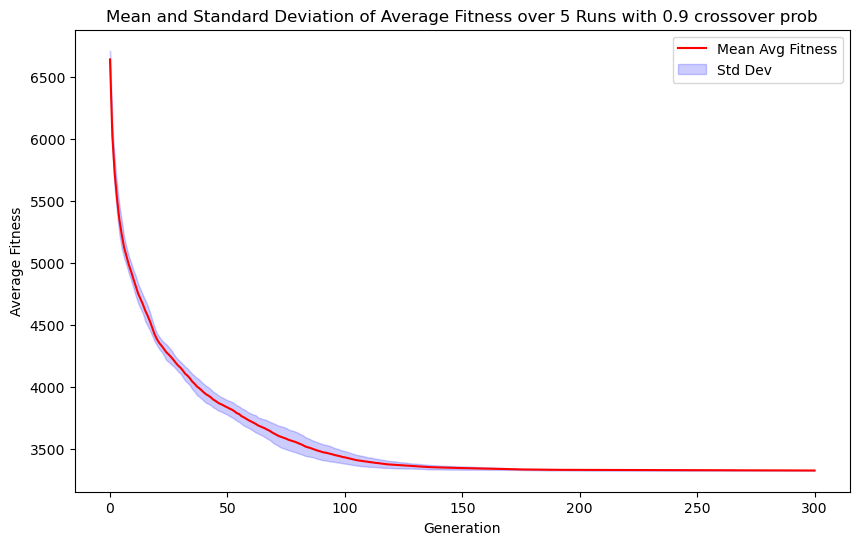

	Best fitness: 3323.0
			Generation: 56
	Best fitness: 3323.0
			Generation: 41
	Best fitness: 3323.0
			Generation: 105
	Best fitness: 3323.0
			Generation: 109
	Best fitness: 3323.0
			Generation: 130


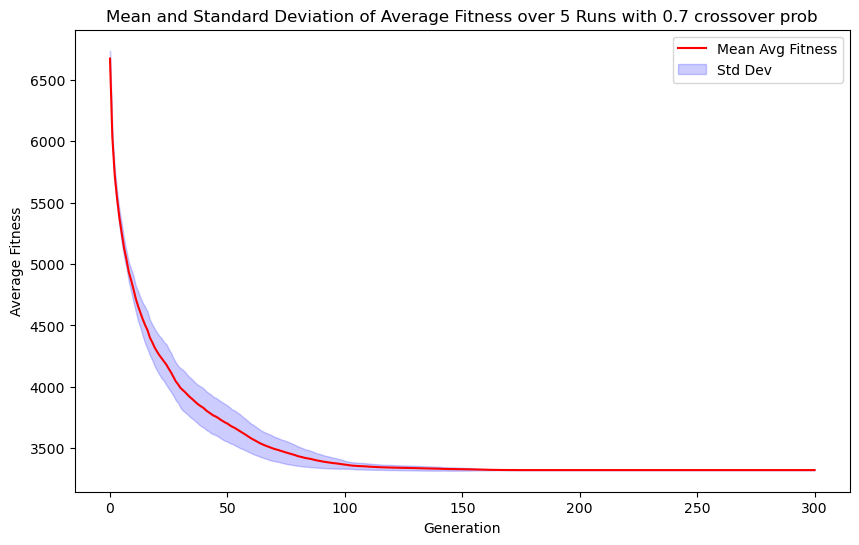

	Best fitness: 3323.0
			Generation: 112
	Best fitness: 3323.0
			Generation: 91
	Best fitness: 3336.0
			Generation: 78
	Best fitness: 3371.0
			Generation: 40
	Best fitness: 3323.0
			Generation: 125


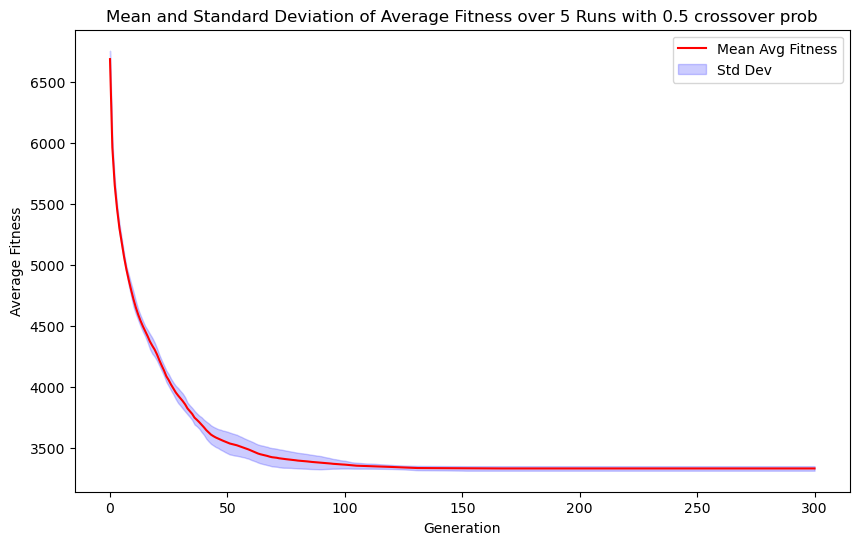

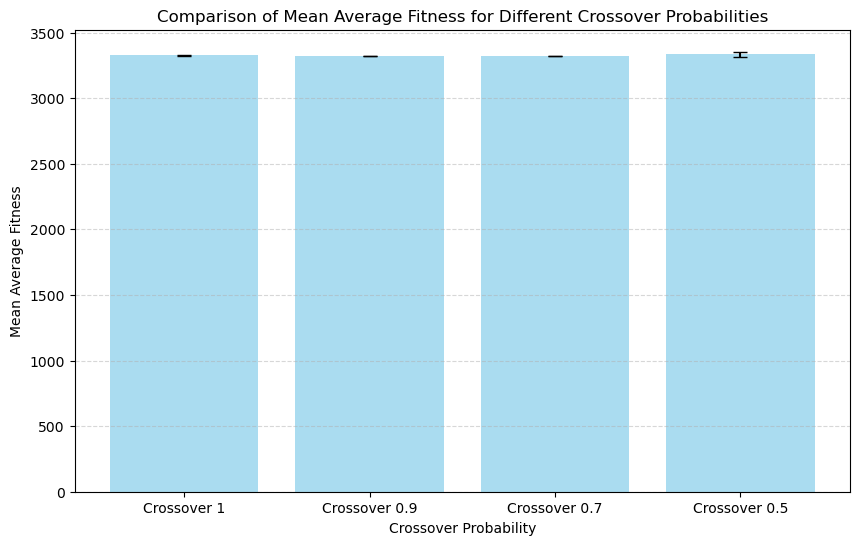

In [9]:
crossover_probs = [1, 0.9, 0.7, 0.5] 
all_mean_avg_fitness = []
all_std_avg_fitness = []

for crossover_prob in crossover_probs:
    fitness_values = []
    for _ in range(num_runs):
        bf, _, avg_fitness_values,_,bestgen,_ =  genetic_tsp(tsp_file_path,100,crossover_prob,0.1,max_generation)
        avg_fitness_values = np.pad(avg_fitness_values, (0, max_generation +1 - len(avg_fitness_values)), 'constant', constant_values=np.nan)
        fitness_values.append(avg_fitness_values)
        print("\tBest fitness:",bf[best_gen])
        print("\t\t\tGeneration:",bestgen)
        
    fitness_values = np.array(fitness_values)
    mean_avg_fitness = np.mean(fitness_values, axis=0)
    std_avg_fitness = np.std(fitness_values, axis=0)
    generations = np.arange(len(mean_avg_fitness))
    plt.figure(figsize=(10, 6))
    plt.plot(generations, mean_avg_fitness, label='Mean Avg Fitness', color='red')
    plt.fill_between(generations, mean_avg_fitness - std_avg_fitness, mean_avg_fitness + std_avg_fitness, color='b', alpha=0.2, label='Std Dev')
    plt.xlabel('Generation')
    plt.ylabel('Average Fitness')
    plt.title(f'Mean and Standard Deviation of Average Fitness over 5 Runs with {crossover_prob} crossover prob')
    plt.legend()
    plt.show()
    all_mean_avg_fitness.append(mean_avg_fitness[-1])
    all_std_avg_fitness.append(std_avg_fitness[-1])

plt.figure(figsize=(10, 6))
x = np.arange(len(crossover_probs))
plt.bar(x, all_mean_avg_fitness, yerr=all_std_avg_fitness, capsize=5, alpha=0.7, color='skyblue')

plt.xticks(x, [f'Crossover {p}' for p in crossover_probs])
plt.xlabel('Crossover Probability')
plt.ylabel('Mean Average Fitness')
plt.title('Comparison of Mean Average Fitness for Different Crossover Probabilities')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

	Best fitness: 3943.0
			Generation: 119
	Best fitness: 3993.0
			Generation: 219
	Best fitness: 3880.0
			Generation: 26
	Best fitness: 3968.0
			Generation: 288
	Best fitness: 4139.0
			Generation: 226


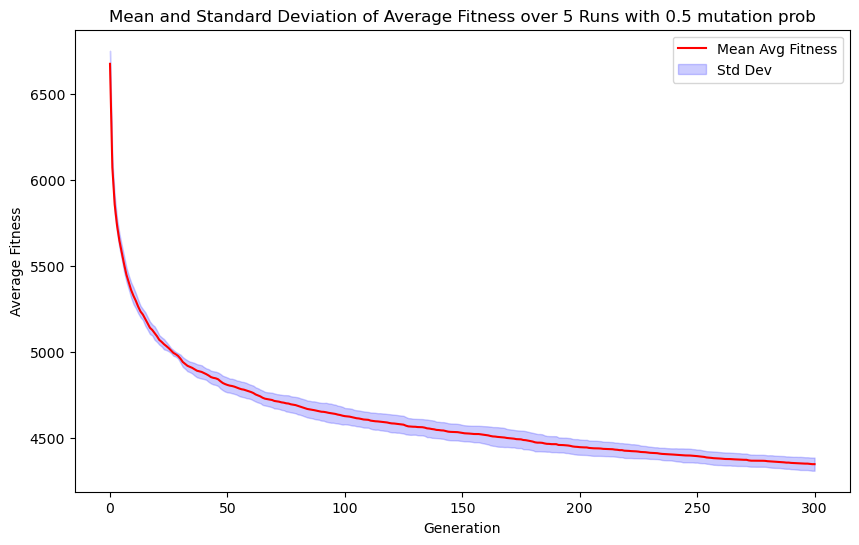

	Best fitness: 3718.0
			Generation: 193
	Best fitness: 3732.0
			Generation: 280
	Best fitness: 3506.0
			Generation: 157
	Best fitness: 3599.0
			Generation: 285
	Best fitness: 3751.0
			Generation: 247


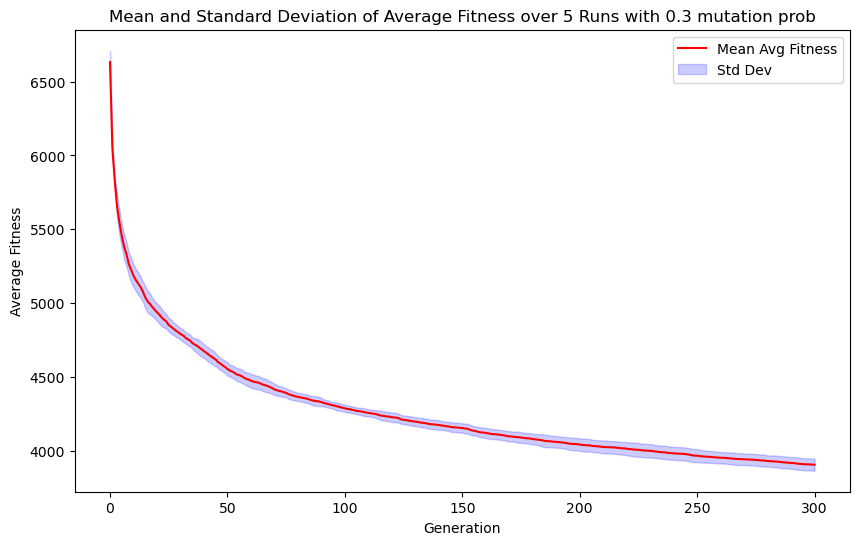

	Best fitness: 3323.0
			Generation: 98
	Best fitness: 3346.0
			Generation: 116
	Best fitness: 3323.0
			Generation: 101
	Best fitness: 3336.0
			Generation: 199
	Best fitness: 3346.0
			Generation: 164


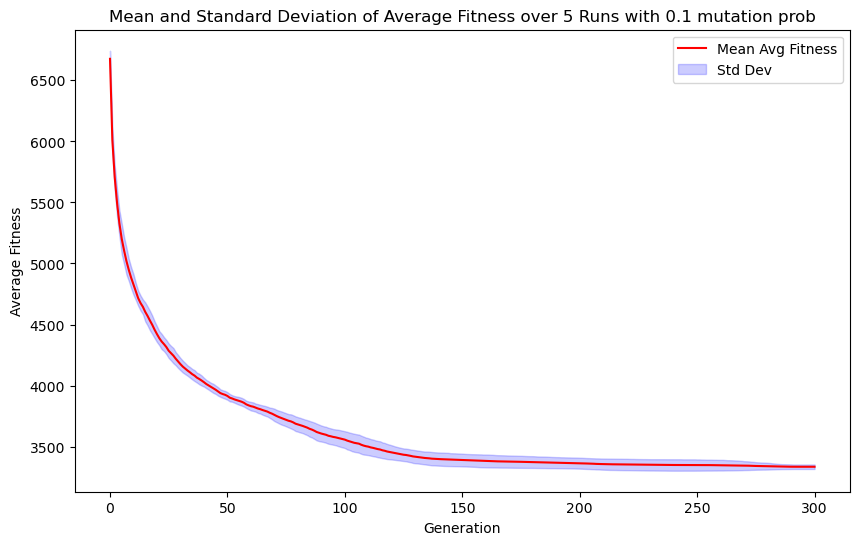

	Best fitness: 3323.0
			Generation: 73
	Best fitness: 3323.0
			Generation: 67
	Best fitness: 3323.0
			Generation: 61
	Best fitness: 3323.0
			Generation: 64
	Best fitness: 3336.0
			Generation: 175


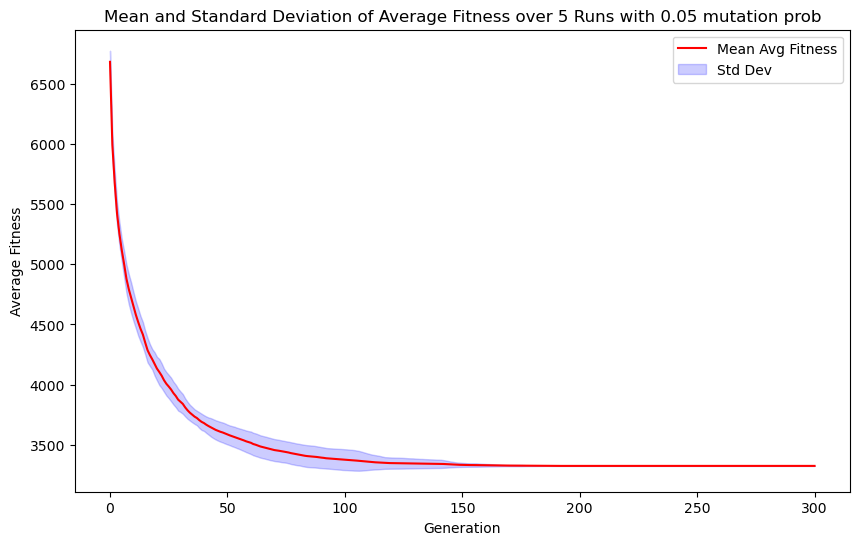

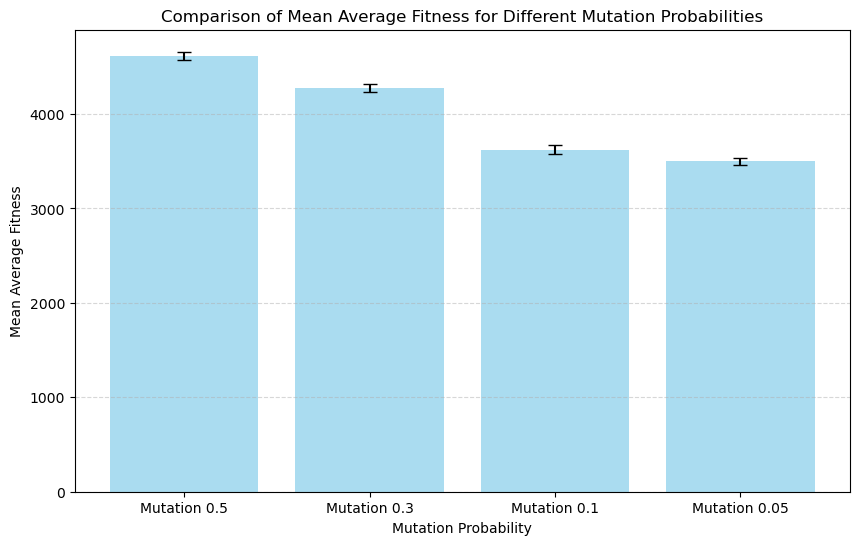

In [10]:
mutation_probs = [0.5 ,0.3 ,0.1, 0.05]
all_mean_avg_fitness = []
all_std_avg_fitness = []

for mutation_prob in mutation_probs:
    fitness_values = []
    for _ in range(num_runs):
        bf, _, avg_fitness_values,_,bestgen,_ = genetic_tsp(tsp_file_path,100,0.9,mutation_prob,max_generation)
        avg_fitness_values = np.pad(avg_fitness_values, (0, max_generation + 1 - len(avg_fitness_values)), 'constant', constant_values=np.nan)
        fitness_values.append(avg_fitness_values)
        print("\tBest fitness:",bf[best_gen])
        print("\t\t\tGeneration:",bestgen)
        
    fitness_values = np.array(fitness_values)
    mean_avg_fitness = np.mean(fitness_values, axis=0)
    std_avg_fitness = np.std(fitness_values, axis=0)
    generations = np.arange(len(mean_avg_fitness))
    plt.figure(figsize=(10, 6))
    plt.plot(generations, mean_avg_fitness, label='Mean Avg Fitness', color='red')
    plt.fill_between(generations, mean_avg_fitness - std_avg_fitness, mean_avg_fitness + std_avg_fitness, color='b', alpha=0.2, label='Std Dev')
    plt.xlabel('Generation')
    plt.ylabel('Average Fitness')
    plt.title(f'Mean and Standard Deviation of Average Fitness over 5 Runs with {mutation_prob} mutation prob')
    plt.legend()
    plt.show()

    fitness_values = np.array(fitness_values)
    mean_avg_fitness = np.mean(fitness_values, axis=0)
    std_avg_fitness = np.std(fitness_values, axis=0)
    
    all_mean_avg_fitness.append(np.nanmean(mean_avg_fitness))
    all_std_avg_fitness.append(np.nanmean(std_avg_fitness))

plt.figure(figsize=(10, 6))
x = np.arange(len(mutation_probs))
plt.bar(x, all_mean_avg_fitness, yerr=all_std_avg_fitness, capsize=5, alpha=0.7, color='skyblue')

plt.xticks(x, [f'Mutation {p}' for p in mutation_probs])
plt.xlabel('Mutation Probability')
plt.ylabel('Mean Average Fitness')
plt.title('Comparison of Mean Average Fitness for Different Mutation Probabilities')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

3323.0 53
3323.0 35
3323.0 32
3323.0 48
3323.0 34


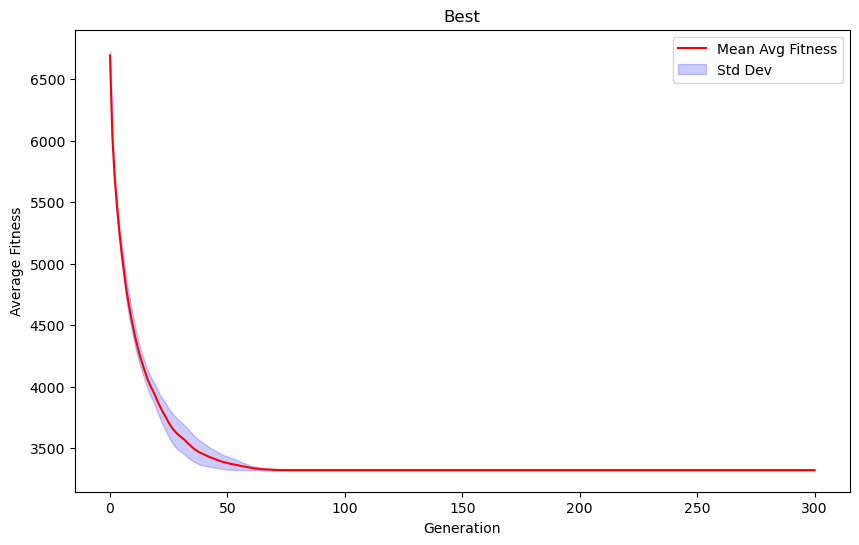

In [13]:
fitness_values = []
num_runs=5
max_generations=300
for _ in range(num_runs):
    bf, _, avg_fitness_values,_,bestgen,_ = genetic_tsp(tsp_file_path,300,0.7,0.05,max_generation)
    avg_fitness_values = np.pad(avg_fitness_values, (0, max_generations + 1 - len(avg_fitness_values)), 'constant', constant_values=np.nan)
    fitness_values.append(avg_fitness_values)
    print(bf[bestgen],bestgen)

fitness_values = np.array(fitness_values)
mean_avg_fitness = np.mean(fitness_values, axis=0)
std_avg_fitness = np.std(fitness_values, axis=0)

generations = np.arange(len(mean_avg_fitness))
plt.figure(figsize=(10, 6))
plt.plot(generations, mean_avg_fitness, label='Mean Avg Fitness', color='red')
plt.fill_between(generations, mean_avg_fitness - std_avg_fitness, mean_avg_fitness + std_avg_fitness, color='b', alpha=0.2, label='Std Dev')
plt.xlabel('Generation')
plt.ylabel('Average Fitness')
plt.title('Best')
plt.legend()
plt.show()


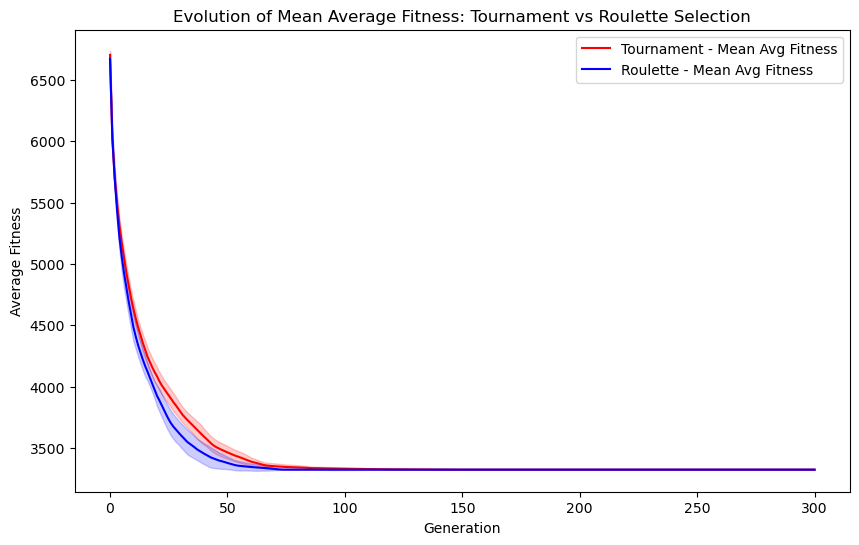

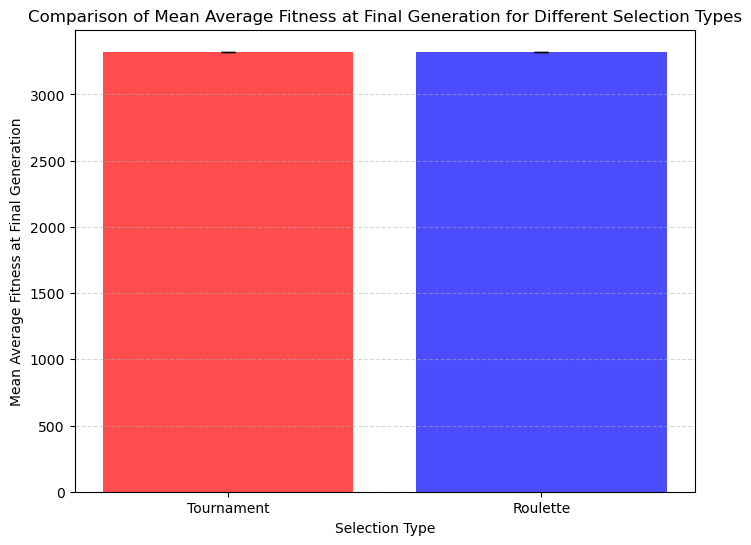

In [14]:
fitness_values_tournament = []
fitness_values_roulette = []
num_runs = 5
max_generations = 300

for _ in range(num_runs):
    bf, _, avg_fitness_values, _, bestgen, _ = genetic_tsp(tsp_file_path,300,0.7,0.05,max_generation,selection_type='Tournament')
    avg_fitness_values = np.pad(avg_fitness_values, (0, max_generations + 1 - len(avg_fitness_values)), 'constant', constant_values=np.nan)
    fitness_values_tournament.append(avg_fitness_values)

for _ in range(num_runs):
    bf, _, avg_fitness_values, _, bestgen, _ =  genetic_tsp(tsp_file_path,300,0.7,0.05,max_generation,selection_type='Roulette')
    avg_fitness_values = np.pad(avg_fitness_values, (0, max_generations + 1 - len(avg_fitness_values)), 'constant', constant_values=np.nan)
    fitness_values_roulette.append(avg_fitness_values)

fitness_values_tournament = np.array(fitness_values_tournament)
fitness_values_roulette = np.array(fitness_values_roulette)

mean_avg_fitness_tournament = np.mean(fitness_values_tournament, axis=0)
std_avg_fitness_tournament = np.std(fitness_values_tournament, axis=0)

mean_avg_fitness_roulette = np.mean(fitness_values_roulette, axis=0)
std_avg_fitness_roulette = np.std(fitness_values_roulette, axis=0)

generations = np.arange(len(mean_avg_fitness_tournament))
plt.figure(figsize=(10, 6))
plt.plot(generations, mean_avg_fitness_tournament, label='Tournament - Mean Avg Fitness', color='red')
plt.fill_between(generations, mean_avg_fitness_tournament - std_avg_fitness_tournament, mean_avg_fitness_tournament + std_avg_fitness_tournament, color='red', alpha=0.2)

plt.plot(generations, mean_avg_fitness_roulette, label='Roulette - Mean Avg Fitness', color='blue')
plt.fill_between(generations, mean_avg_fitness_roulette - std_avg_fitness_roulette, mean_avg_fitness_roulette + std_avg_fitness_roulette, color='blue', alpha=0.2)

plt.xlabel('Generation')
plt.ylabel('Average Fitness')
plt.title('Evolution of Mean Average Fitness: Tournament vs Roulette Selection')
plt.legend()
plt.show()

final_mean_avg_fitness = [mean_avg_fitness_tournament[-1], mean_avg_fitness_roulette[-1]]
final_std_avg_fitness = [std_avg_fitness_tournament[-1], std_avg_fitness_roulette[-1]]

plt.figure(figsize=(8, 6))
x = np.arange(2)
plt.bar(x, final_mean_avg_fitness, yerr=final_std_avg_fitness, capsize=5, alpha=0.7, color=['red', 'blue'])
plt.xticks(x, ['Tournament', 'Roulette'])
plt.xlabel('Selection Type')
plt.ylabel('Mean Average Fitness at Final Generation')
plt.title('Comparison of Mean Average Fitness at Final Generation for Different Selection Types')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


